# Cluster HFpEF

In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sn

from IPython.display import display

from preproc import get_hfpef_405, convert2np

In [2]:
no_clusters = 6
lbl_colname= ['Death', 'CV death', 'Major cardiac events', 'HF re-hospitalization']

## Get Data

In [3]:
data_df = get_hfpef_405()

In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 398 entries, 0 to 404
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    398 non-null    int64  
 1   Sex                    398 non-null    int64  
 2   Cr                     398 non-null    float64
 3   GFR                    398 non-null    float64
 4   CKD stage              398 non-null    int64  
 5   smoke                  398 non-null    float64
 6   BMI                    398 non-null    float64
 7   BSA                    398 non-null    float64
 8   DM                     398 non-null    int64  
 9   Insulin                398 non-null    int64  
 10  AF                     398 non-null    int64  
 11  SBP                    398 non-null    int64  
 12  DBP                    398 non-null    int64  
 13  MAP                    398 non-null    float64
 14  PP                     398 non-null    int64  
 15  1/2SBP

In [6]:
data_df.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,BSA,DM,Insulin,...,E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LVH,LAVI,LACI,LA diameter,LVEF
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.00000,...,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,72.369347,1.673367,1.561156,54.485302,2.723618,0.070352,26.756283,1.636097,0.582915,0.18593,...,0.724947,16.783819,1.849573,0.586359,113.987915,2.723618,35.115578,3.472730,3.834351,62.252261
std,11.212253,0.469572,1.317699,24.350964,0.995706,0.256061,6.617308,0.230709,0.493698,0.38954,...,0.589102,8.684397,1.414765,0.348421,51.265226,1.990910,26.129318,4.026239,1.318855,8.656340
min,31.000000,1.000000,0.550000,2.000000,1.000000,0.000000,15.400000,1.120000,0.000000,0.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,65.000000,1.000000,0.880000,38.000000,2.000000,0.000000,22.400000,1.500000,0.000000,0.00000,...,0.479750,11.200000,0.000000,0.370000,86.900000,1.000000,18.375000,0.000000,3.600000,57.000000
50%,74.000000,2.000000,1.160000,55.500000,3.000000,0.000000,26.000000,1.600000,1.000000,0.00000,...,0.700000,15.850000,2.440000,0.500000,113.000000,3.000000,35.300000,2.734398,4.000000,62.000000
75%,81.000000,2.000000,1.580000,71.000000,3.000000,0.000000,30.375000,1.800000,1.000000,0.00000,...,1.000000,22.100000,2.997500,0.720000,141.635000,4.000000,50.500000,5.605634,4.481975,67.000000
max,97.000000,2.000000,10.000000,108.000000,5.000000,1.000000,55.900000,2.300000,1.000000,1.00000,...,4.100000,42.200000,4.550000,2.300000,356.600000,7.000000,140.800000,23.665480,7.000000,82.900000


## 1. All Features

In [7]:
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture

from sklearn.pipeline import make_pipeline

from utils import get_score, score_columns, plot_contingency_matrix, plot_bic_aic, plot_clustering_score
from methods import get_sc_pred, get_km_pred, get_gm_pred

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

In [8]:
X, y, feature_list = convert2np(data_df, lbl_colname)

C:\Users\sguly\Documents\HFpEF\preproc.py:55: UserWarning: Warning...........selected_feat is not given, set to 0 where all features are used.
  warnings.warn("Warning...........selected_feat is not given, set to 0 where all features are used.")


In [9]:
X.shape

(398, 47)

In [10]:
all_dfs = []
for f in [get_sc_pred, get_km_pred, get_gm_pred]:
    dfs = []
    for i in range(y.shape[1]):
        df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, no_clusters)],
                          columns=score_columns)
        dfs.append(df)
    all_dfs.append(dfs)

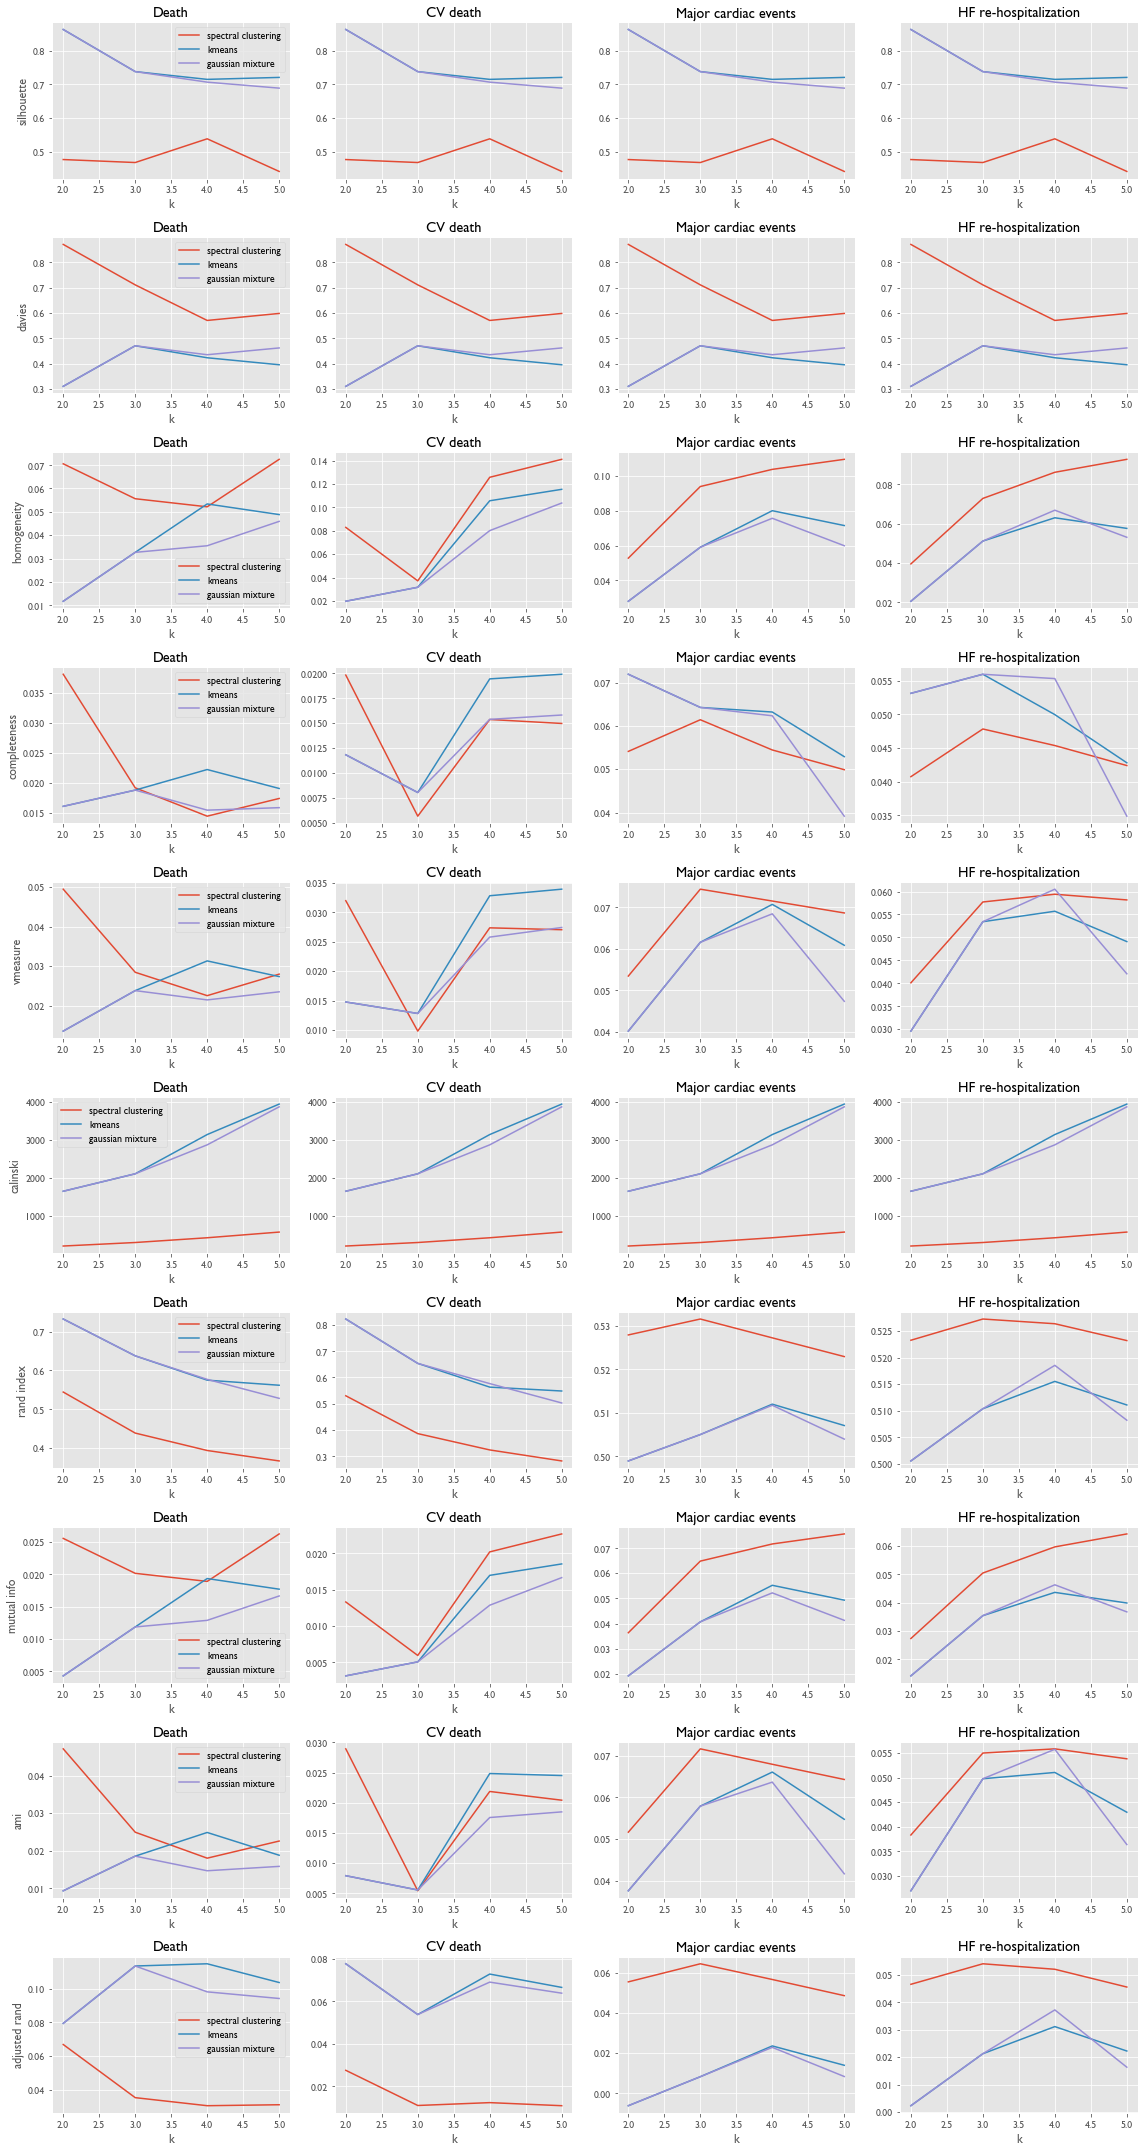

In [11]:
methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

plot_clustering_score(all_dfs, methods, lbl_colname, savefig='report_score_405.png')

The meaning of the scores.
<!-- * `BIC` lower is better
* `AIC` lower is better -->
* `silhouette` higher is better
* `davies` lower is better
* `homogeneity` higher is better
* `completeness` higher is better
* `v-measure` higher is better
* `calinski` higher is better
* `v-measure` higher is better
* `calinski` higher is better
* `rand index` higher is better
* `mutual info` higher is better

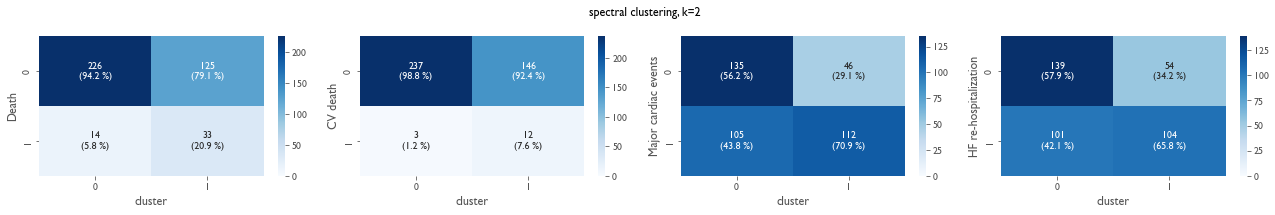

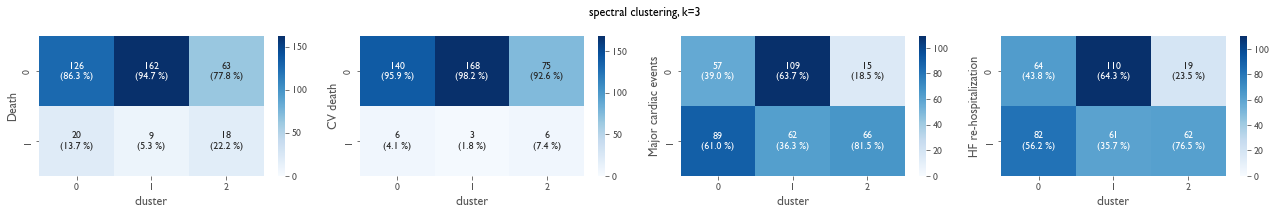

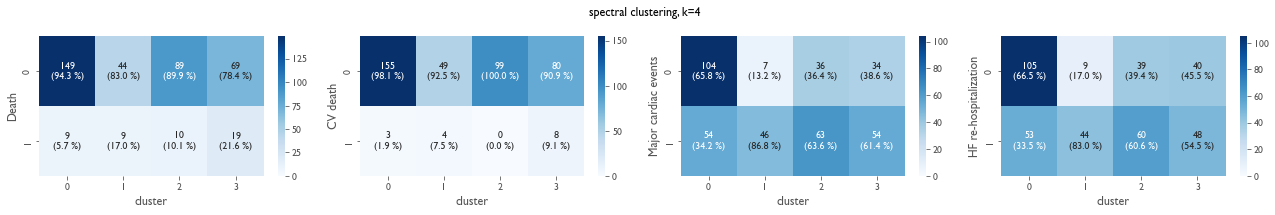

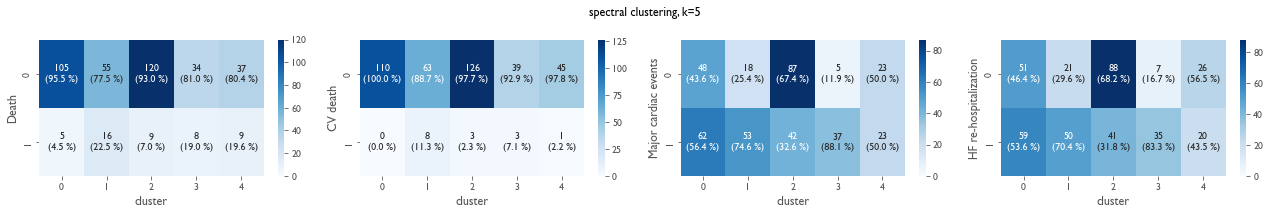

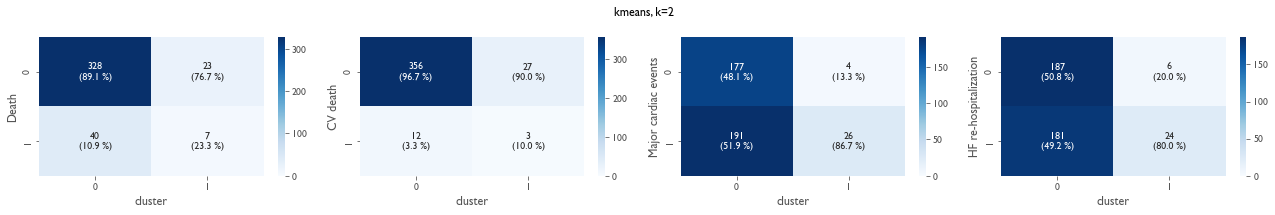

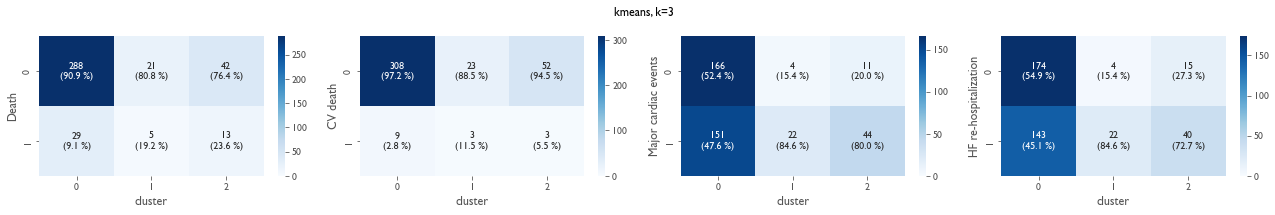

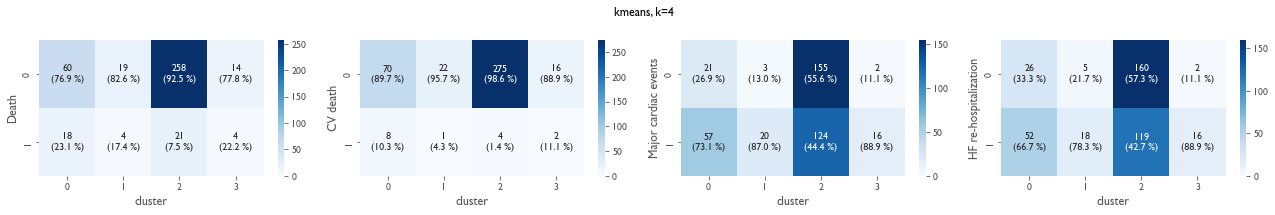

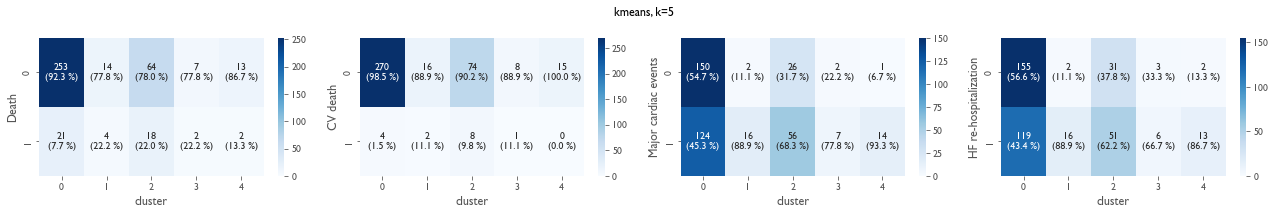

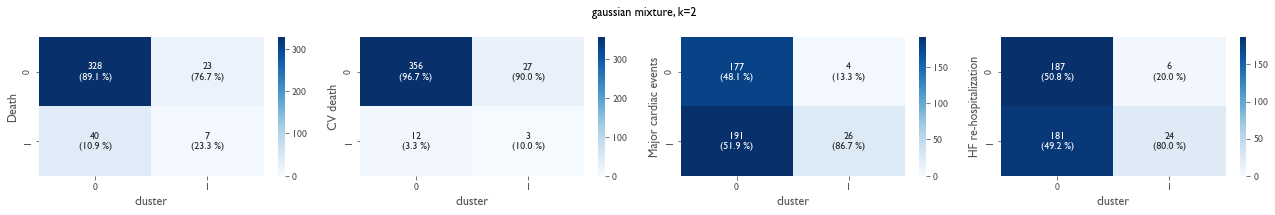

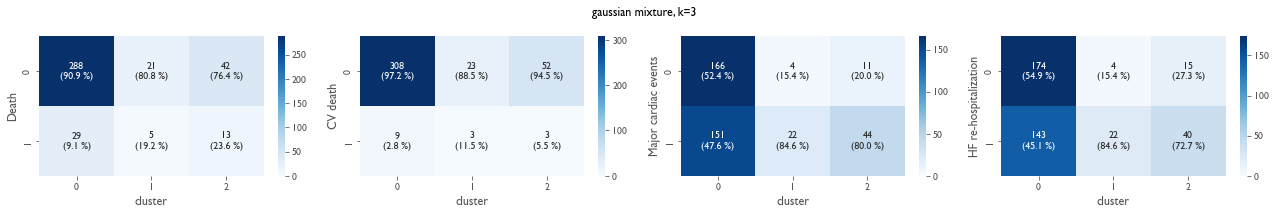

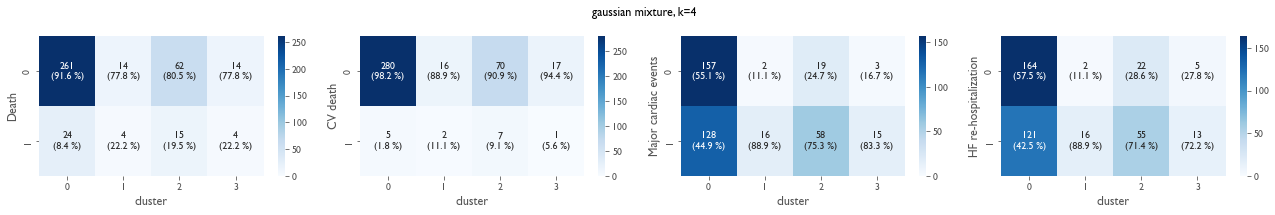

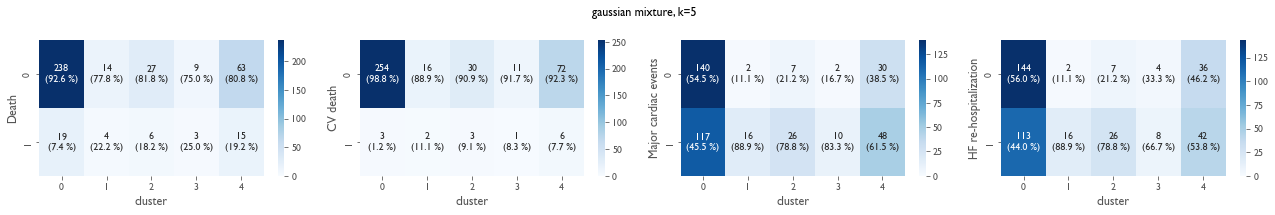

In [12]:
plot_contingency_matrix(all_dfs, methods, lbl_colname, savefig='report_table')

In [13]:
# for i, lbl in enumerate(lbl_colname):
#     display(lbl)
#     for j, met in enumerate(methods):
#         display(met)
#         display(all_dfs[j][i])

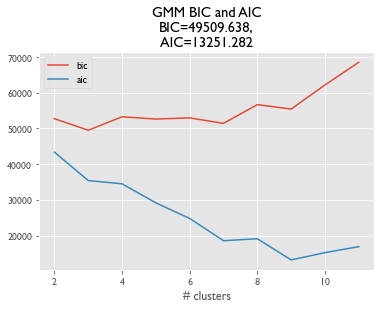

In [14]:
bics, aics = plot_bic_aic(X)

## 2. Selected Feature

In [15]:
X, y, feature_list = convert2np(data_df, lbl_colname, selected_feat=1)

In [16]:
X.shape

(398, 13)

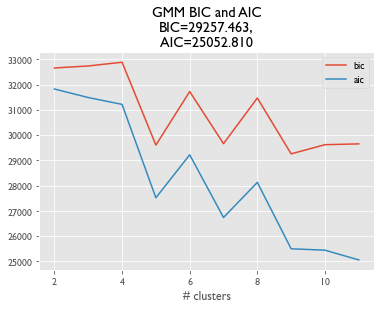

In [17]:
bics, aics = plot_bic_aic(X)

In [18]:
all_dfs = []
for f in [get_sc_pred, get_km_pred, get_gm_pred]:
    dfs = []
    for i in range(y.shape[1]):
        df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, no_clusters)],
                          columns=score_columns)
        dfs.append(df)
    all_dfs.append(dfs)

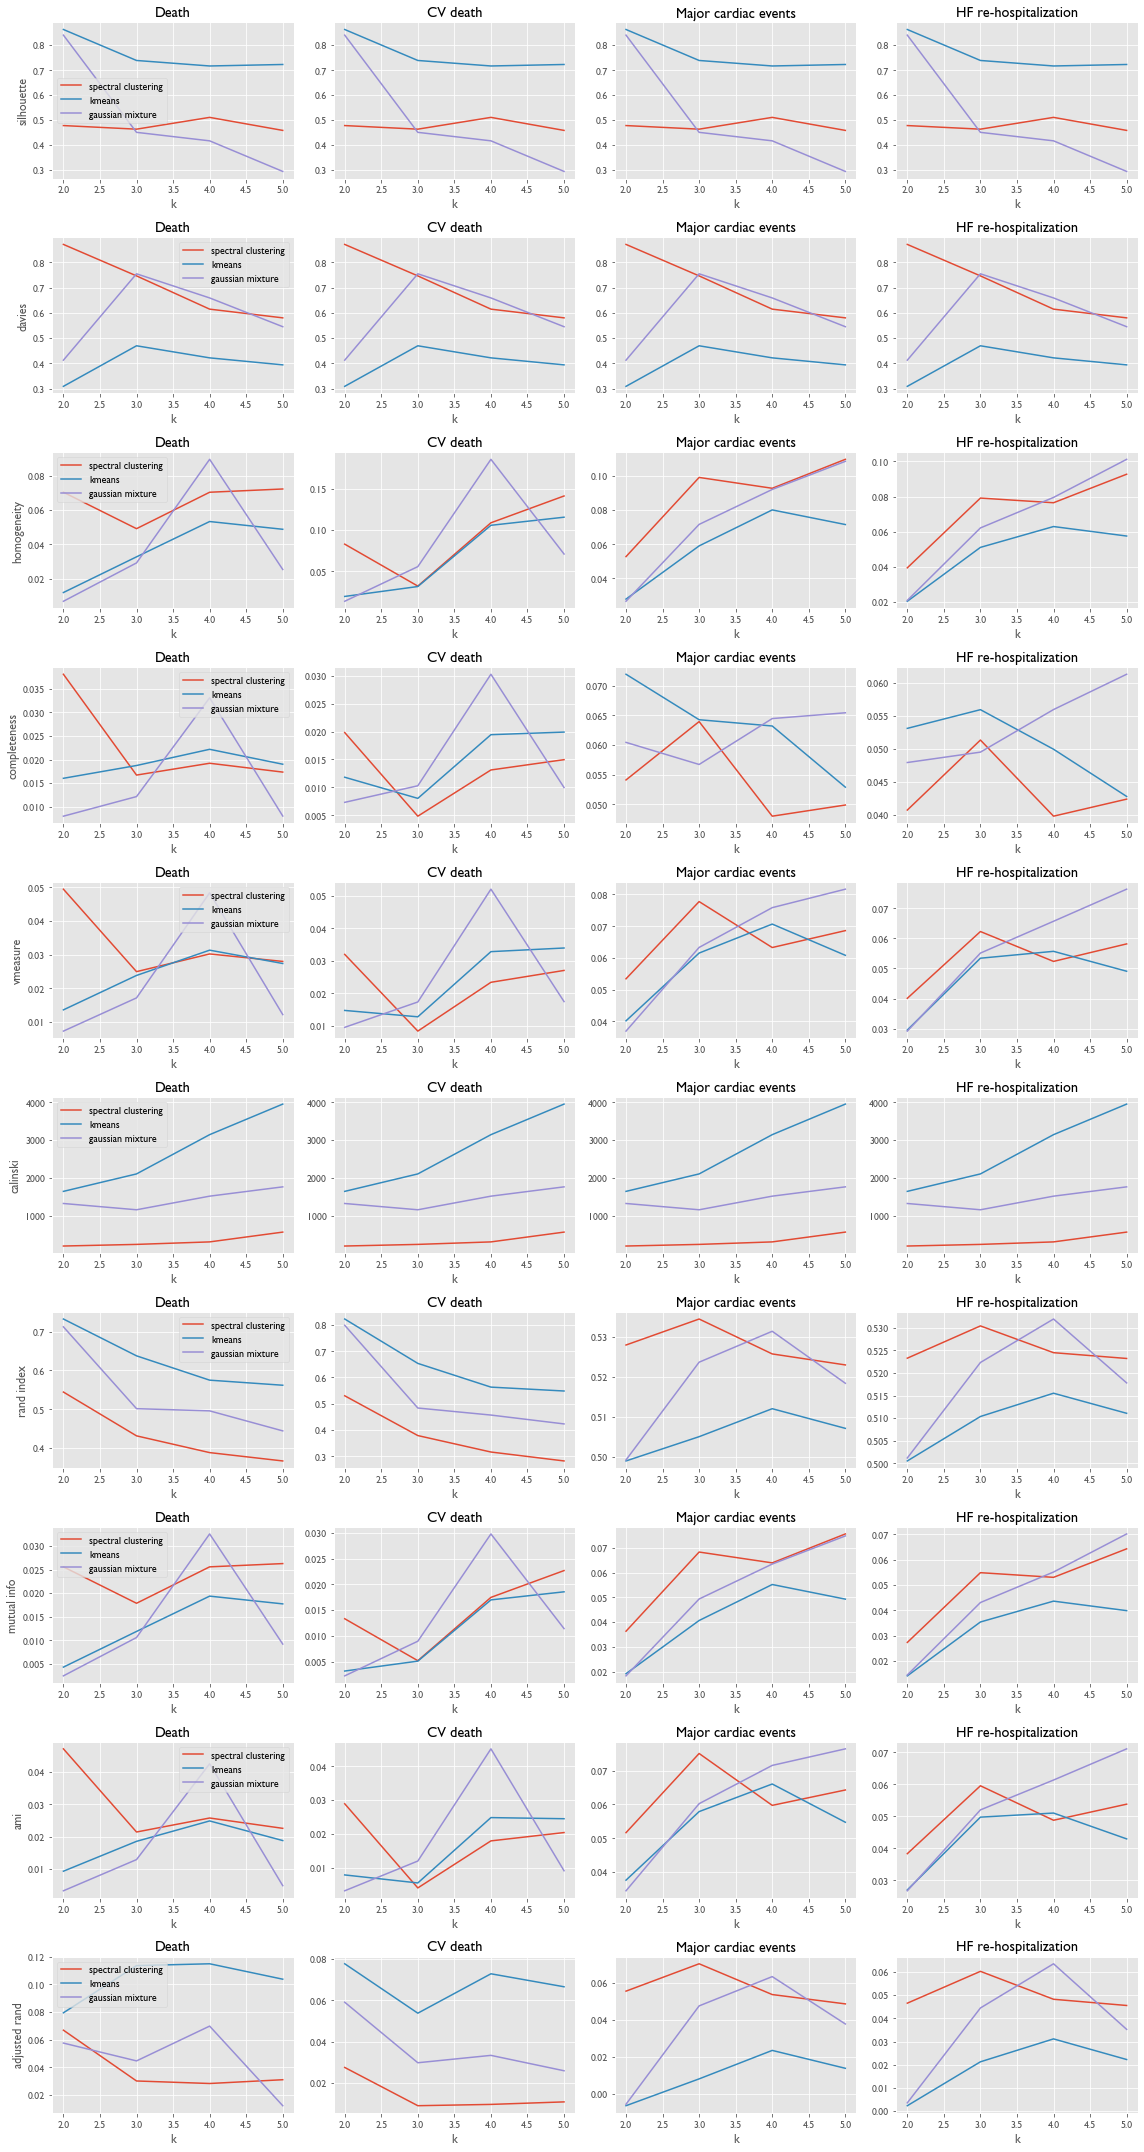

In [19]:
methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

plot_clustering_score(all_dfs, methods, lbl_colname)

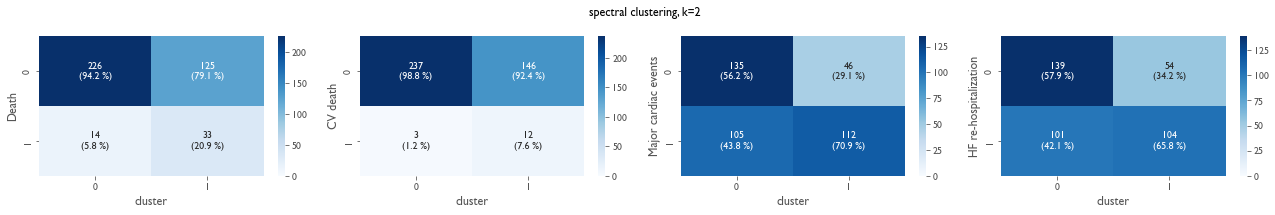

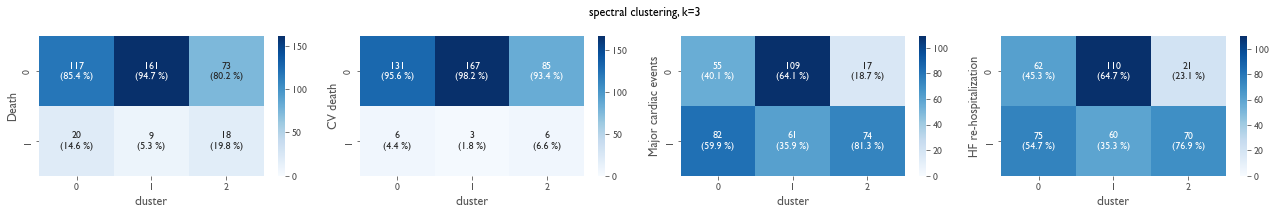

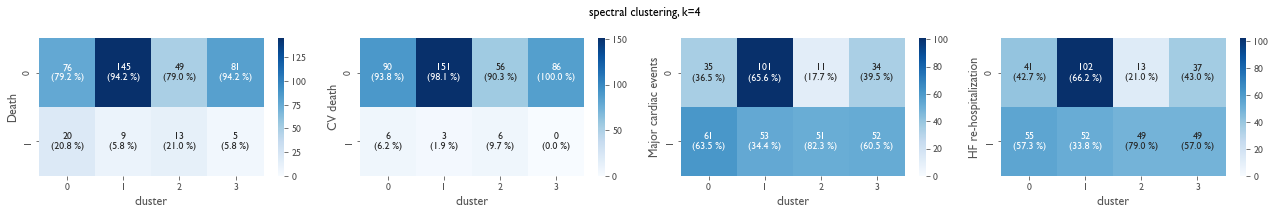

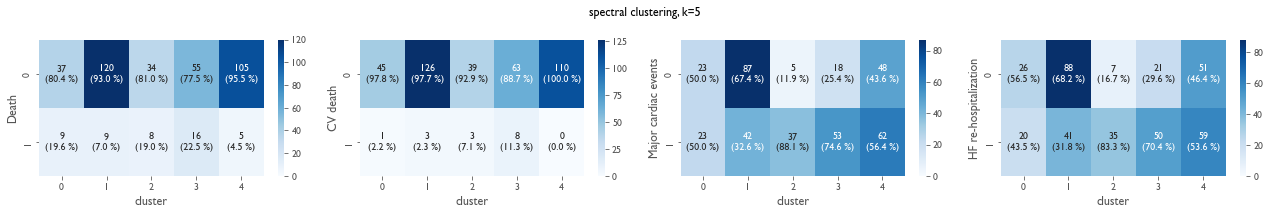

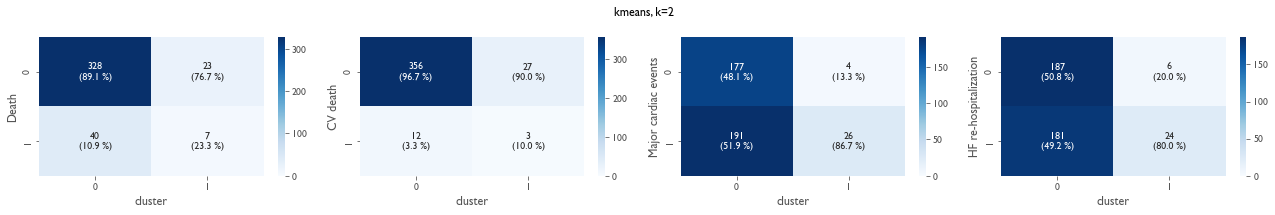

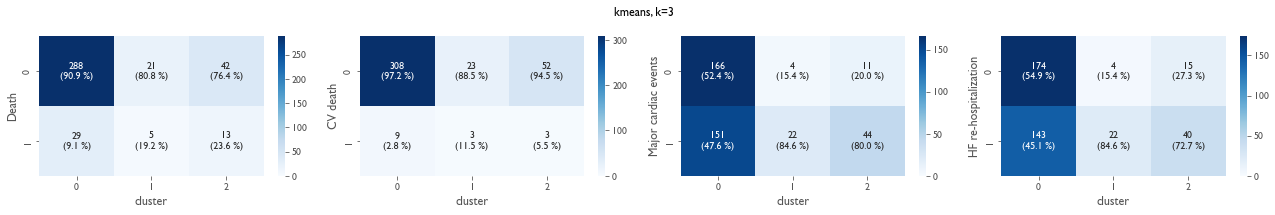

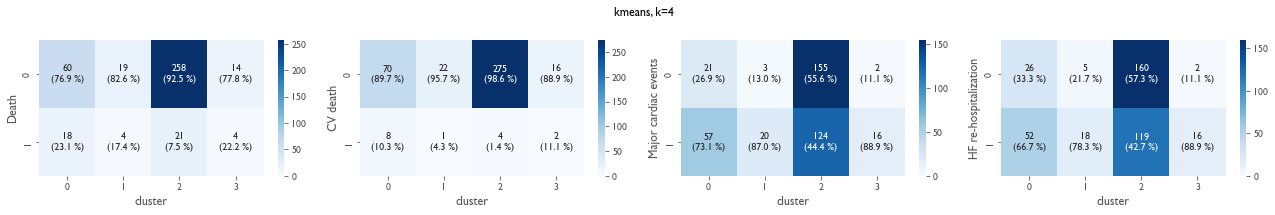

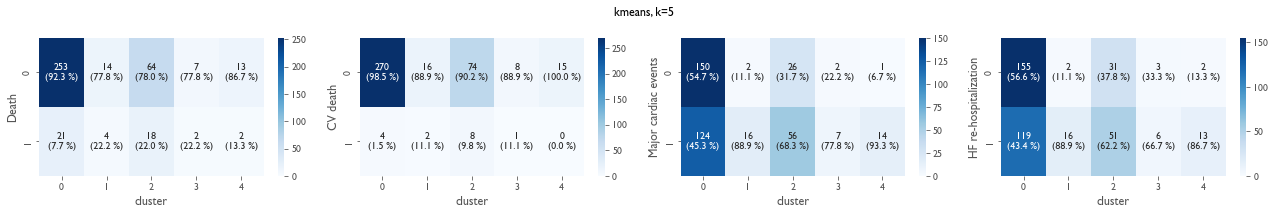

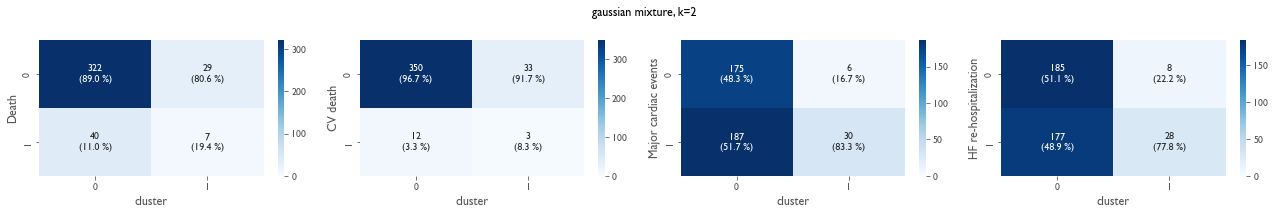

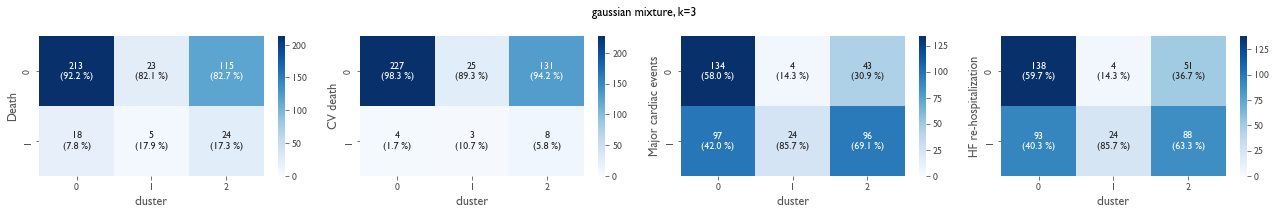

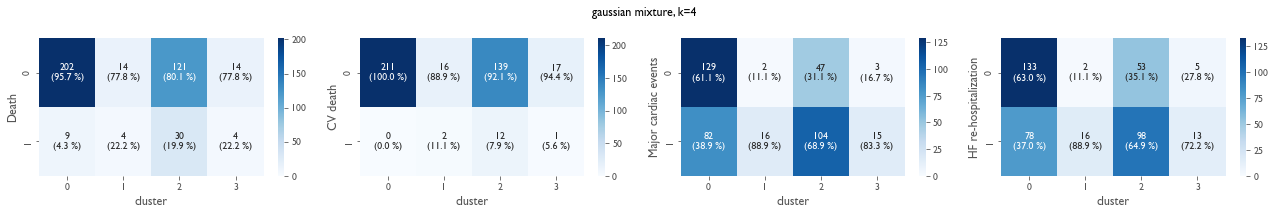

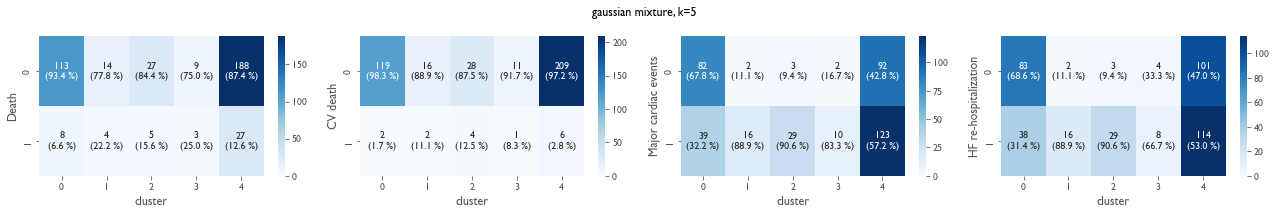

In [20]:
plot_contingency_matrix(all_dfs, methods, lbl_colname)

## 3. Selected Feature Based on PCA

In [21]:
X, y, feature_list = convert2np(data_df, lbl_colname, selected_feat=2)

In [22]:
X.shape

(398, 1)

In [23]:
all_dfs = []
for f in [get_sc_pred, get_km_pred, get_gm_pred]:
    dfs = []
    for i in range(y.shape[1]):
        df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, no_clusters)],
                          columns=score_columns)
        dfs.append(df)
    all_dfs.append(dfs)

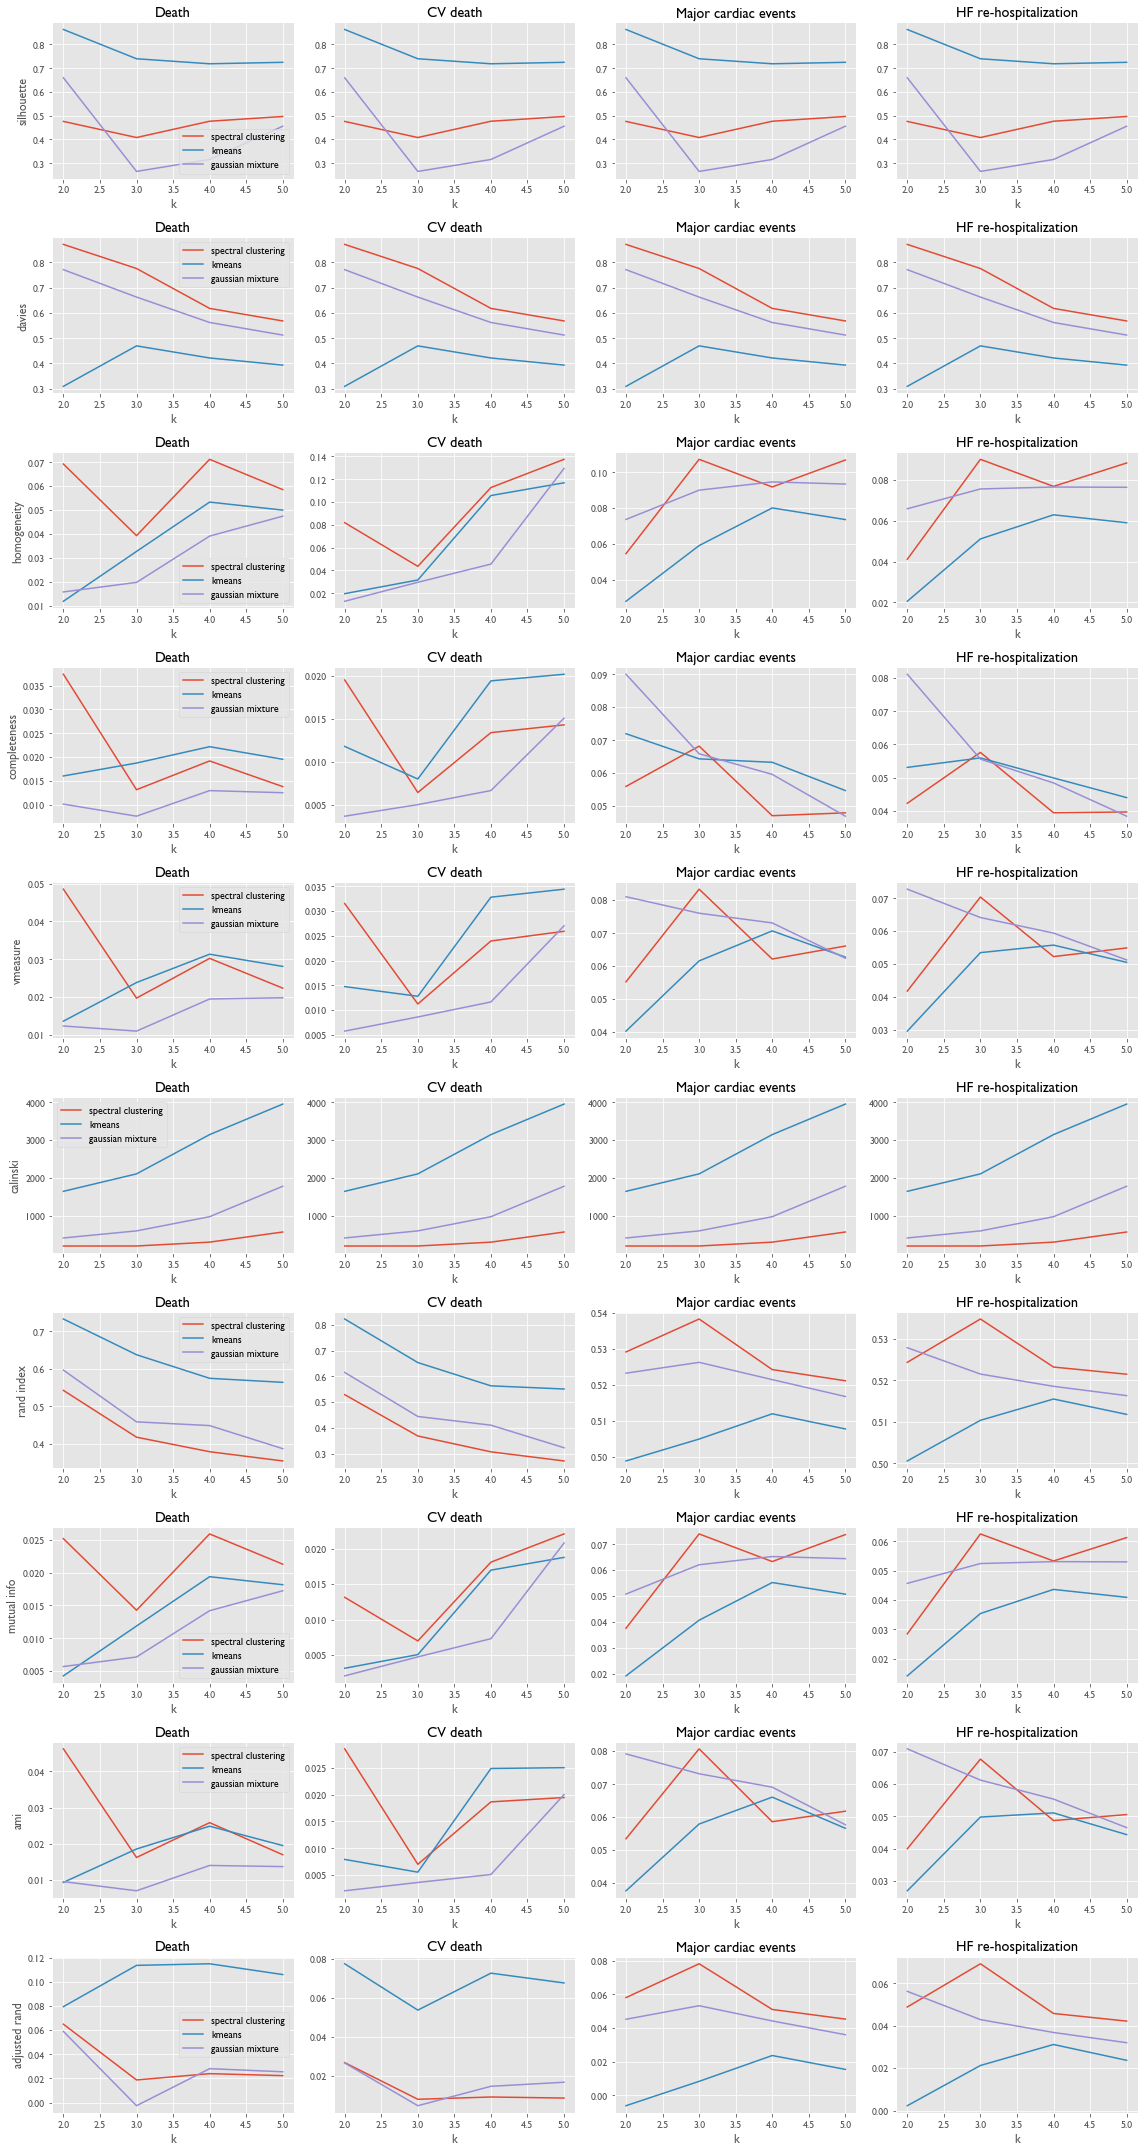

In [24]:
methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

plot_clustering_score(all_dfs, methods, lbl_colname)

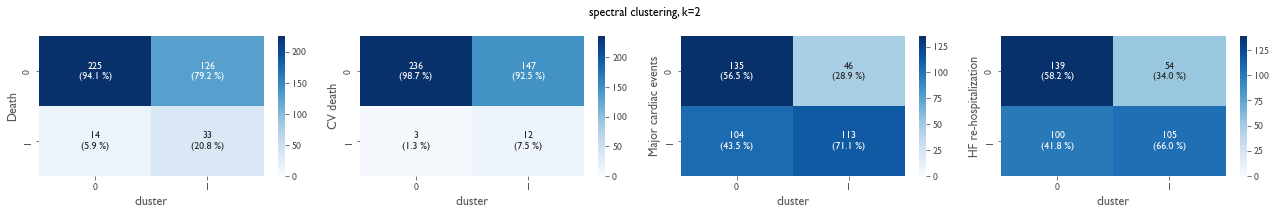

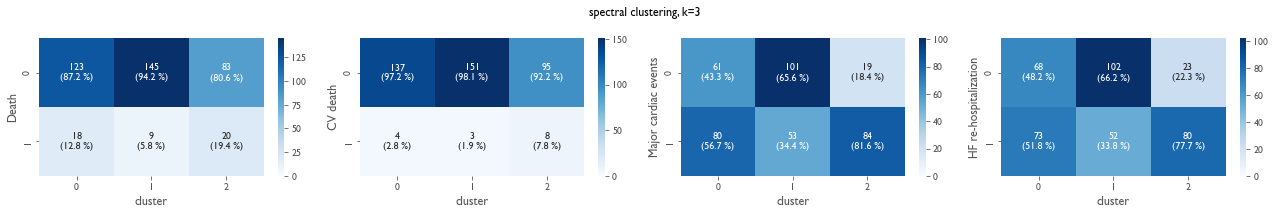

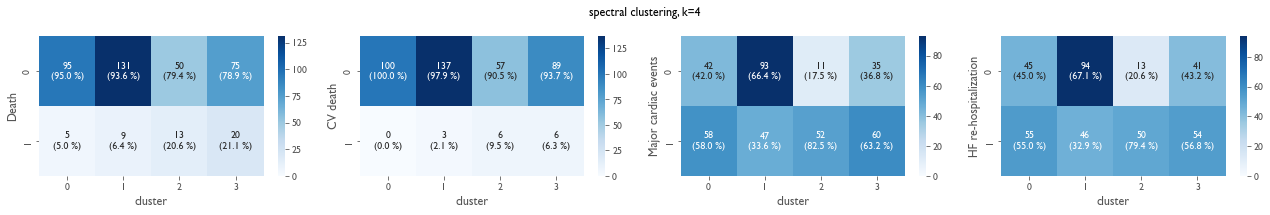

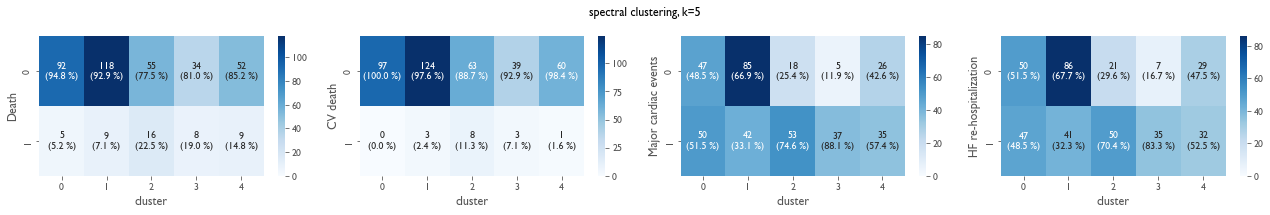

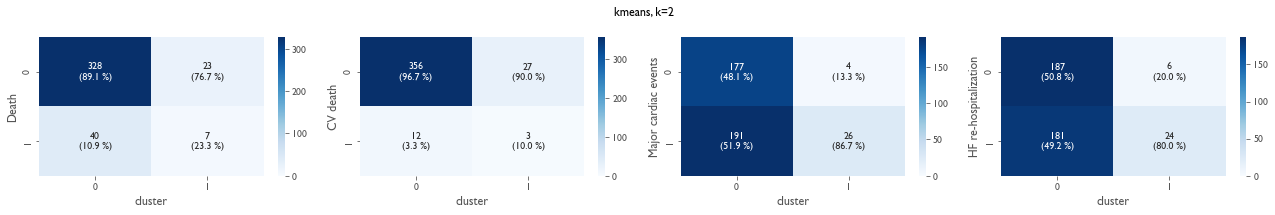

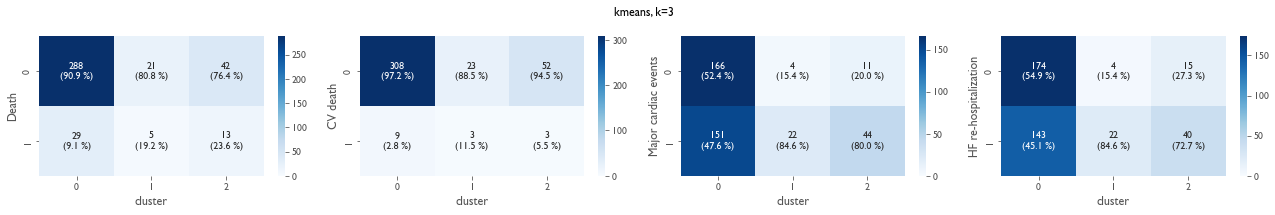

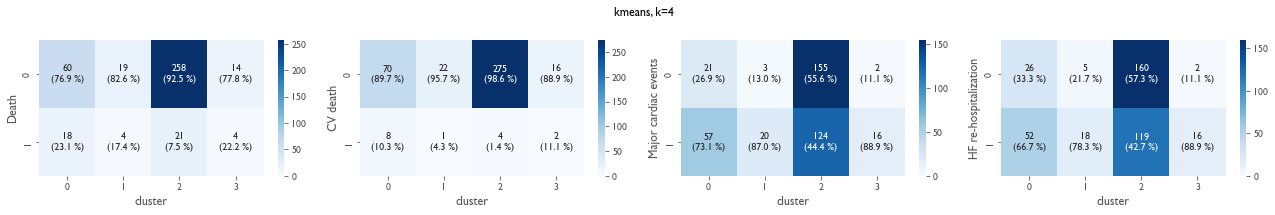

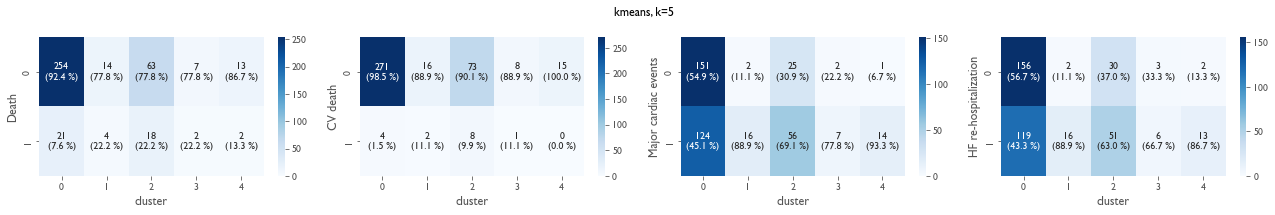

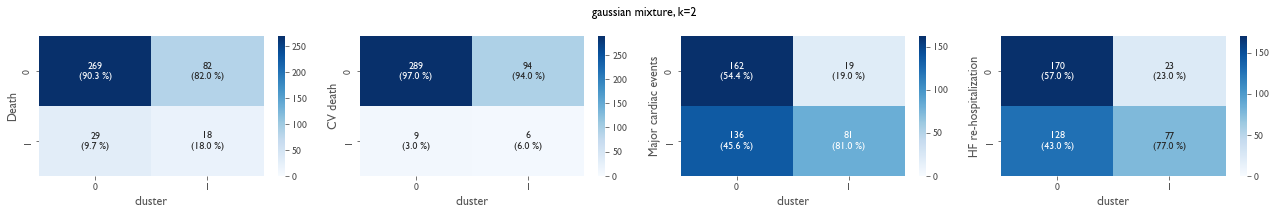

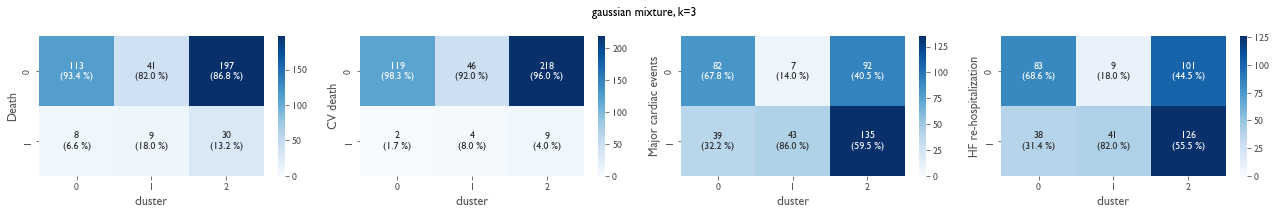

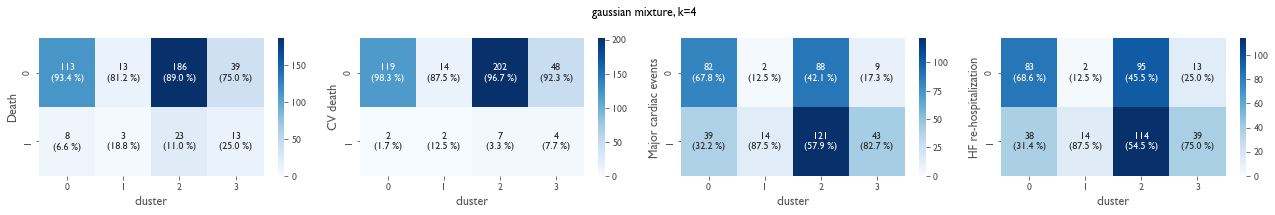

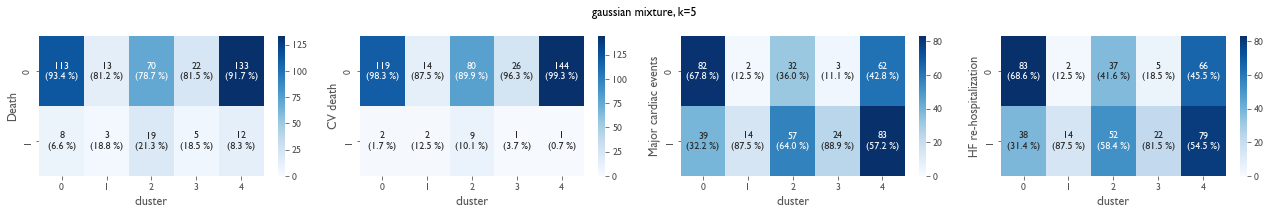

In [25]:
plot_contingency_matrix(all_dfs, methods, lbl_colname)

## Get Cleaned Data

In [26]:
data_df_nomiss = get_hfpef_405(nomiss=True)

In [28]:
data_df_nomiss.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 145 entries, 1 to 404
Data columns (total 51 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    145 non-null    int64  
 1   Sex                    145 non-null    int64  
 2   Cr                     145 non-null    float64
 3   GFR                    145 non-null    float64
 4   CKD stage              145 non-null    int64  
 5   smoke                  145 non-null    float64
 6   BMI                    145 non-null    float64
 7   BSA                    145 non-null    float64
 8   DM                     145 non-null    int64  
 9   Insulin                145 non-null    int64  
 10  AF                     145 non-null    int64  
 11  SBP                    145 non-null    int64  
 12  DBP                    145 non-null    int64  
 13  MAP                    145 non-null    float64
 14  PP                     145 non-null    int64  
 15  1/2SBP

In [29]:
data_df_nomiss.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,BSA,DM,Insulin,...,E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LVH,LAVI,LACI,LA diameter,LVEF
count,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,...,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000
mean,71.137931,1.662069,1.495862,57.476138,2.586207,0.048276,26.388664,1.622939,0.627586,0.193103,...,0.958621,19.368897,1.935793,0.612117,123.608276,3.082759,41.753103,5.875199,4.039503,62.730345
std,11.297505,0.474644,1.248331,25.388228,1.010955,0.215092,6.303211,0.208831,0.485124,0.396102,...,0.429899,8.612584,1.371418,0.329848,42.068062,2.019019,18.469833,3.981753,0.665267,7.601474
min,31.000000,1.000000,0.600000,2.000000,1.000000,0.000000,15.400000,1.200000,0.000000,0.000000,...,0.400000,4.290000,0.000000,0.230000,53.800000,0.000000,12.500000,1.695652,2.100000,50.000000
25%,64.000000,1.000000,0.870000,39.000000,2.000000,0.000000,21.900000,1.500000,0.000000,0.000000,...,0.700000,12.800000,0.000000,0.400000,94.400000,1.000000,29.300000,3.482659,3.659000,57.300000
50%,73.000000,2.000000,1.160000,60.000000,3.000000,0.000000,25.600000,1.600000,1.000000,0.000000,...,0.900000,17.500000,2.390000,0.522000,117.800000,4.000000,38.900000,4.821151,4.000000,61.000000
75%,79.000000,2.000000,1.520000,75.000000,3.000000,0.000000,29.600000,1.800000,1.000000,0.000000,...,1.200000,23.500000,3.050000,0.700000,145.100000,4.000000,48.300000,6.955836,4.400000,67.000000
max,92.000000,2.000000,10.000000,108.000000,5.000000,1.000000,44.400000,2.300000,1.000000,1.000000,...,3.200000,42.200000,4.550000,2.300000,356.600000,7.000000,107.700000,23.665480,6.500000,80.000000


## 4. Cleaned Data

In [30]:
X, y, feature_list = convert2np(data_df_nomiss, lbl_colname, selected_feat=1)

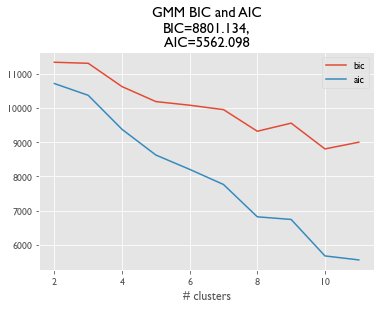

In [31]:
bics, aics = plot_bic_aic(X)

In [32]:
# all_dfs = []
# for f in [get_sc_pred, get_km_pred, get_gm_pred]:
#     dfs = []
#     for i in range(y.shape[1]):
#         df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, no_clusters)],
#                           columns=score_columns)
#         dfs.append(df)
#     all_dfs.append(dfs)

In [33]:
# methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

# plot_clustering_score(all_dfs, methods, lbl_colname)

In [34]:
# plot_contingency_matrix(all_dfs, methods, lbl_colname)

In [35]:
# for i, lbl in enumerate(lbl_colname):
#     display(lbl)
#     for j, met in enumerate(methods):
#         display(met)
#         display(all_dfs[j][i])